# Brain Tumor 3D Segmentation with MONAI SegRegNet Model
Purpose is to train a `SegRegNet` model to preform segmentation on Brain Tumor MRI images.  The dataset used for training is available from [medical decathlon](http://medicaldecathlon.com/) and has the following characteristics:
- **Target**: Glioma segmenation necrotic/active tumor and edema
- **Modality**: FLAIR, T1w, T1gd, and T2w
- **Size**: 750 4D volumes (484 Training and 266 Testing)
- **Source**: BraTS 2016 and 2017 datasets

A paper describing the dataset can be found at [Simpson et al, 2019](https://arxiv.org/abs/1902.09063)

----
<a name='startup_tasks'></a>
## 1.0 <span style='color:blue'>|</span> Common Start Up Tasks

<a name='import_packages'></a>
### 1.1 <span style='color:blue'>|</span> Import Required Packages and Libraries

In [1]:
import os, shutil, tempfile, time, random, gc, warnings, glob
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'        # Fixes a warning from PyTorch
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from typing import List, Tuple, Dict, Optional, Literal
from dataclasses import dataclass
from pathlib import Path

from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import DataLoader, Dataset, decollate_batch
from monai.data import MetaTensor
from monai.inferers import SlidingWindowInferer
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.networks.nets import SegResNet
from monai.networks.utils import one_hot
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    Invertd,
    LoadImage,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    Spacingd,
    Resized,
    ResizeWithPadOrCropd,
    EnsureTyped,
    EnsureChannelFirstd,
    SaveImage
)

from monai.utils import set_determinism
import onnxruntime
from tqdm import tqdm

# Make plots have guidelines
plt.style.use('ggplot')

# Squash Python warnings
warnings.filterwarnings('ignore')

# Enable Python's Garbage Collector
gc.collect()

2026-03-06 08:15:18.619517696 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
<frozen importlib._bootstrap_external>:1325: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-06 08:15:24.758612: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


752

<a name='global_variables'></a>
### 1.2 <span style='color:blue'>|</span> Declare Global Variables and Set Device

In [2]:
SEED = 42
ROOT_DIR = '../monai'
POST_DIR = '../post/PatientID_0015/Timepoint_1'
BEST_DIR = './weights'
OUT_DIR  = '../post/seg_out'
MAX_EPOCHS = 200
VAL_INTERVAL = 1
VAL_AMP = True
NUM_WORKERS = 4
ROI_SIZE = [128, 128, 64]
PIX_DIM = (1.0, 1.0, 1.0)
BATCH_SIZE = 4

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

<a name='random_seed'></a>
### 1.3 <span style='color:blue'>|</span> Set Random Seed for Reproducibility
Not sure if all of these are required, but I have seen consistent results between runs

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
#set_determinism(SEED)

# When running on CuDNN backend, it is recommended to set these two options
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
torch.set_float32_matmul_precision('medium')

----
<a name='classes_functions'></a>
## 2.0 <span style='color:blue'>|</span> Define Classes and Functions

<a name='convert_multichannel'></a>
### 2.1 <span style='color:blue'>|</span> Class to Convert Labels to Multi-Channels

In [4]:
class ConvertToMultiChannel(MapTransform):
    '''
    Convert labels to multi channels based on brats classes:
    label 1 is the peritumoral edema
    label 2 is the GD-enhancing tumor
    label 3 is the necrotic and non-enhancing tumor core
    The possible classes are TC (Tumor core), WT (Whole tumor)
    and ET (Enhancing tumor).
    '''

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # merge label 2 and label 3 to construct TC
            result.append(torch.logical_or(d[key] == 2, d[key] == 3))
            # merge labels 1, 2 and 3 to construct WT
            result.append(torch.logical_or(torch.logical_or(d[key] == 2, d[key] == 3), d[key] == 1))
            # label 2 is ET
            result.append(d[key] == 2)
            d[key] = torch.stack(result, axis=0).float()
        return d

----
<a name='define_work'></a>
## 3.0 <span style='color:blue'>|</span> Do the Work

<a name='define_transforms'></a>
### 3.1 <span style='color:blue'>|</span> Define Transformations to be Used

In [5]:
train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys='image'),
        EnsureTyped(keys=['image', 'label']),
        ConvertToMultiChannel(keys='label'),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(
            keys=['image', 'label'],
            pixdim=(1.0, 1.0, 1.0),
            mode=('bilinear', 'nearest'),
        ),
        RandSpatialCropd(keys=['image', 'label'], roi_size=ROI_SIZE, random_size=False),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
        RandScaleIntensityd(keys='image', factors=0.1, prob=1.0),
        RandShiftIntensityd(keys='image', offsets=0.1, prob=1.0),
    ]
)
val_transform = Compose(
    [
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys='image'),
        EnsureTyped(keys=['image', 'label']),
        ConvertToMultiChannel(keys='label'),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(
            keys=['image', 'label'],
            pixdim=(1.0, 1.0, 1.0),
            mode=('bilinear', 'nearest'),
        ),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
    ]
)

<a name='load_datasets'></a>
### 3.2 <span style='color:blue'>|</span> Load Training and Validation Datasets

In [6]:
train_ds = DecathlonDataset(
    root_dir=ROOT_DIR,
    task='Task01_BrainTumour',
    transform=train_transform,
    section='training',
    download=False,
    cache_rate=0.0,
    num_workers=NUM_WORKERS,
)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=4)

val_ds = DecathlonDataset(
    root_dir=ROOT_DIR,
    task='Task01_BrainTumour',
    transform=val_transform,
    section='validation',
    download=False,
    cache_rate=0.0,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

<a name='display_image'></a>
### 3.3 <span style='color:blue'>|</span> Display an Image's Input Channels and its Output Labels
Display an image's input channels and its corresponding segmentation labels

image shape: torch.Size([4, 240, 240, 155])


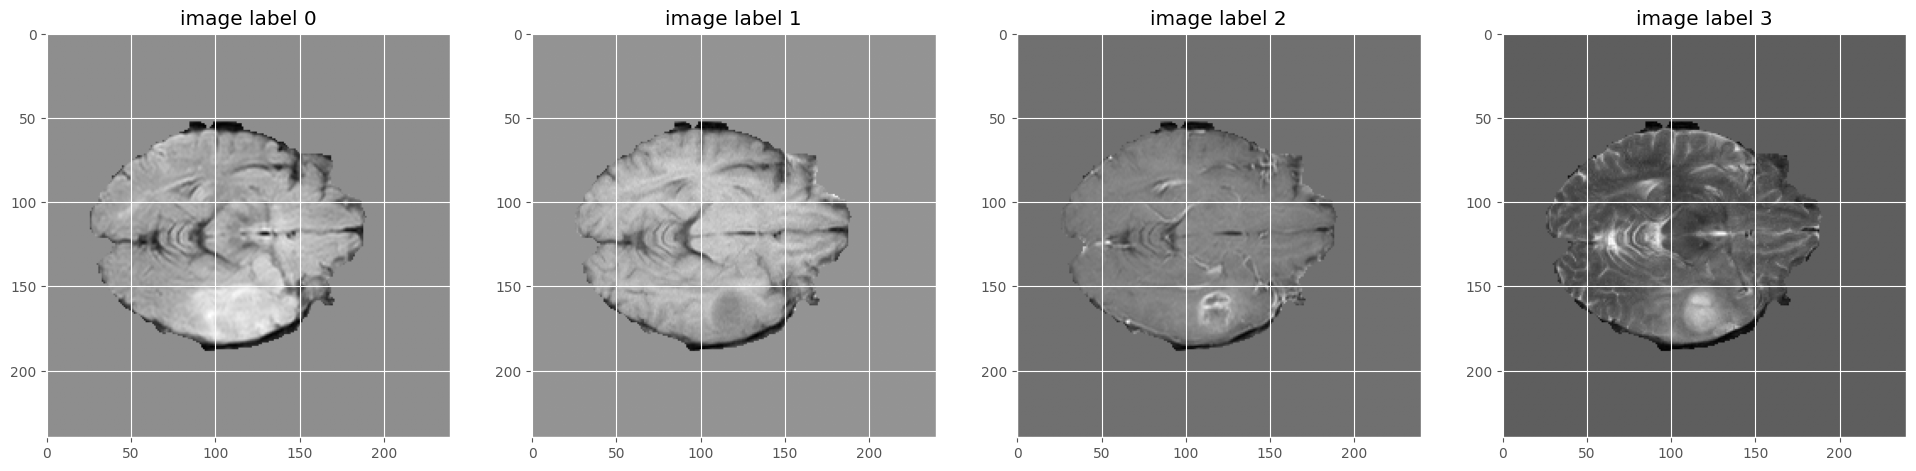

label shape: torch.Size([3, 240, 240, 155])


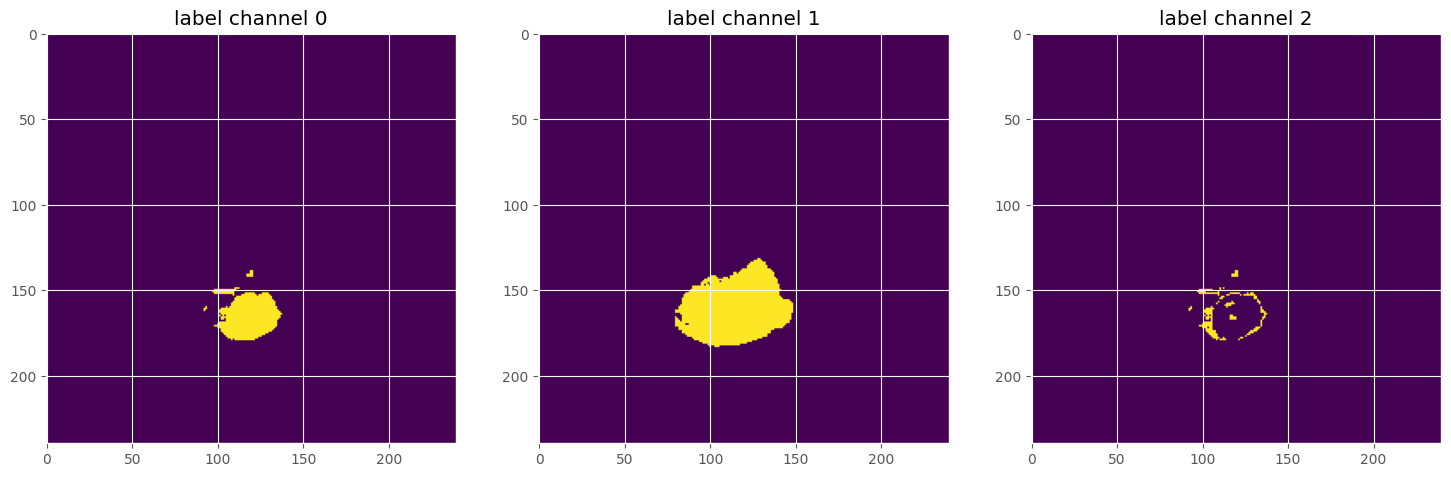

In [7]:
# Pick one image and visualize the different channels
val_data_example = val_ds[2]
print(f'image shape: {val_data_example['image'].shape}')
plt.figure('image', (24, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f'image label {i}')
    plt.imshow(val_data_example['image'][i, :, :, 60].detach().cpu(), cmap='gray')
plt.show()

# Visualize the segmentation labels
print(f'label shape: {val_data_example['label'].shape}')
plt.figure('label', (18, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f'label channel {i}')
    plt.imshow(val_data_example['label'][i, :, :, 60].detach().cpu())
plt.show()

<a name='define_model'></a>
### 3.4 <span style='color:blue'>|</span> Define `SegResNet()` Model, Dice Loss, and the Optimizer

In [8]:
# standard PyTorch program style: create SegResNet, DiceLoss and Adam optimizer
model = SegResNet(
    blocks_down  = [1, 2, 2, 4],
    blocks_up    = [1, 1, 1],
    init_filters = 16,
    in_channels  = 4,
    out_channels = 3,
    dropout_prob = 0.2).to(DEVICE)

loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

dice_metric = DiceMetric(include_background=True, reduction='mean')
dice_metric_batch = DiceMetric(include_background=True, reduction='mean_batch')

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])


# define inference method
def inference(input):
    def _compute(input):
        return sliding_window_inference(
            inputs = input,
            roi_size = ROI_SIZE,
            sw_batch_size = 4,
            predictor = model,
            overlap = 0.5,
        )

    if VAL_AMP:
        with torch.autocast('cuda'):
            return _compute(input)
    else:
        return _compute(input)


# use amp to accelerate training
scaler = torch.GradScaler('cuda')
# enable cuDNN benchmark
torch.backends.cudnn.benchmark = True

<a name='train_model'></a>
### 3.5 <span style='color:blue'>|</span> Train Model using Custom Early Stopping Callback

In [9]:
# Early stopping parameters
patience = 10
min_delta = 0.001
best_metric = -1
best_metric_epoch = -1
early_stop_counter = 0
early_stop_triggered = False

best_metrics_epochs_and_time = [[], [], []]
epoch_loss_values = []
metric_values = []
metric_values_tc = []
metric_values_wt = []
metric_values_et = []

total_start = time.time()
for epoch in tqdm(range(MAX_EPOCHS), desc='Training Epochs'):
    epoch_start = time.time()
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step_start = time.time()
        step += 1
        inputs, labels = (
            batch_data['image'].to(DEVICE),
            batch_data['label'].to(DEVICE),
        )
        optimizer.zero_grad()
        with torch.autocast('cuda'):
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    lr_scheduler.step()
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)

    if (epoch + 1) % VAL_INTERVAL == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data['image'].to(DEVICE),
                    val_data['label'].to(DEVICE),
                )
                val_outputs = inference(val_inputs)
                val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
                dice_metric(y_pred=val_outputs, y=val_labels)
                dice_metric_batch(y_pred=val_outputs, y=val_labels)

            metric = dice_metric.aggregate().item()
            metric_values.append(metric)
            metric_batch = dice_metric_batch.aggregate()
            metric_tc = metric_batch[0].item()
            metric_values_tc.append(metric_tc)
            metric_wt = metric_batch[1].item()
            metric_values_wt.append(metric_wt)
            metric_et = metric_batch[2].item()
            metric_values_et.append(metric_et)
            dice_metric.reset()
            dice_metric_batch.reset()

            if metric > best_metric + min_delta:
                best_metric = metric
                best_metric_epoch = epoch + 1
                best_metrics_epochs_and_time[0].append(best_metric)
                best_metrics_epochs_and_time[1].append(best_metric_epoch)
                best_metrics_epochs_and_time[2].append(time.time() - total_start)
                torch.save(
                    model.state_dict(),
                    os.path.join(BEST_DIR,'best_metric_model.pth'),
                )
                print('saved new best metric model')
                early_stop_counter = 0  # reset counter on improvement
            else:
                early_stop_counter += 1  # no improvement -> increment counter

                print(f'current epoch: {epoch + 1} current mean dice: {metric:.4f}'
                    f' tc: {metric_tc:.4f} wt: {metric_wt:.4f} et: {metric_et:.4f}'
                    f'\nbest mean dice: {best_metric:.4f} at epoch: {best_metric_epoch}'
                    f'\nearly stop counter: {early_stop_counter}/{patience}'
                )

            # Check for early stopping trigger
            if early_stop_counter >= patience:
                print(f'\nEarly stopping triggered at epoch {epoch + 1}')
                early_stop_triggered = True
                break  # exit the epoch loop 

Training Epochs:   0%|▏                             | 1/200 [02:12<7:17:51, 132.02s/it]

saved new best metric model


Training Epochs:   1%|▎                             | 2/200 [04:13<6:54:24, 125.58s/it]

saved new best metric model


Training Epochs:   2%|▍                             | 3/200 [06:14<6:45:29, 123.50s/it]

...

current epoch: 43 current mean dice: 0.7168 tc: 0.7668 wt: 0.8658 et: 0.5177
best mean dice: 0.7262 at epoch: 35
early stop counter: 8/10


Training Epochs:  22%|█████▉                     | 44/200 [1:30:11<5:22:12, 123.93s/it]

current epoch: 44 current mean dice: 0.7253 tc: 0.7784 wt: 0.8878 et: 0.5097
best mean dice: 0.7262 at epoch: 35
early stop counter: 9/10


Training Epochs:  22%|█████▉                     | 44/200 [1:32:12<5:26:56, 125.75s/it]

current epoch: 45 current mean dice: 0.7131 tc: 0.7710 wt: 0.8683 et: 0.4998
best mean dice: 0.7262 at epoch: 35
early stop counter: 10/10

Early stopping triggered at epoch 45


----
<a name='evaluate_performance'></a>
## 4.0 <span style='color:blue'>|</span> Evaluate Performance

<a name='evaluate_training'></a>
### 4.1 <span style='color:blue'>|</span> Evaluate Training/Validation Performance

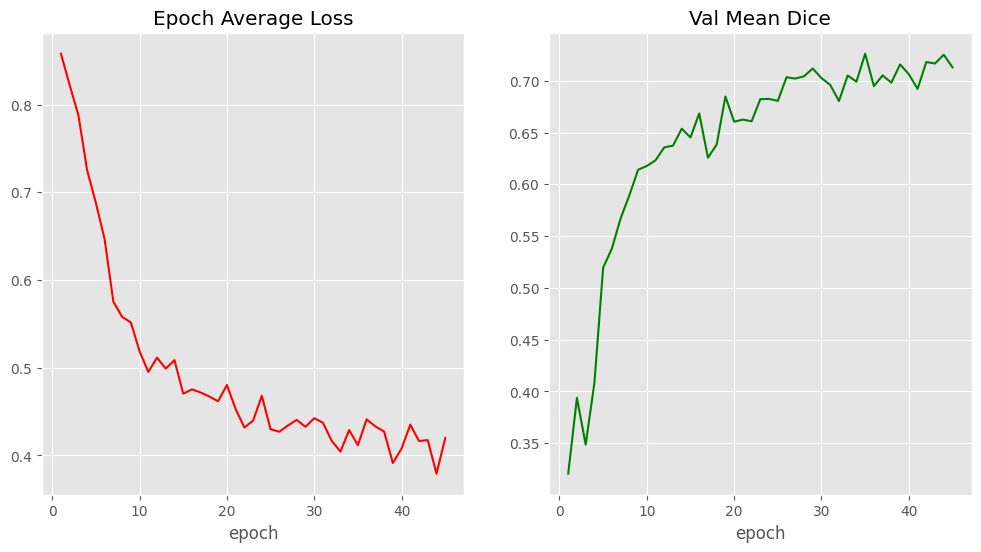

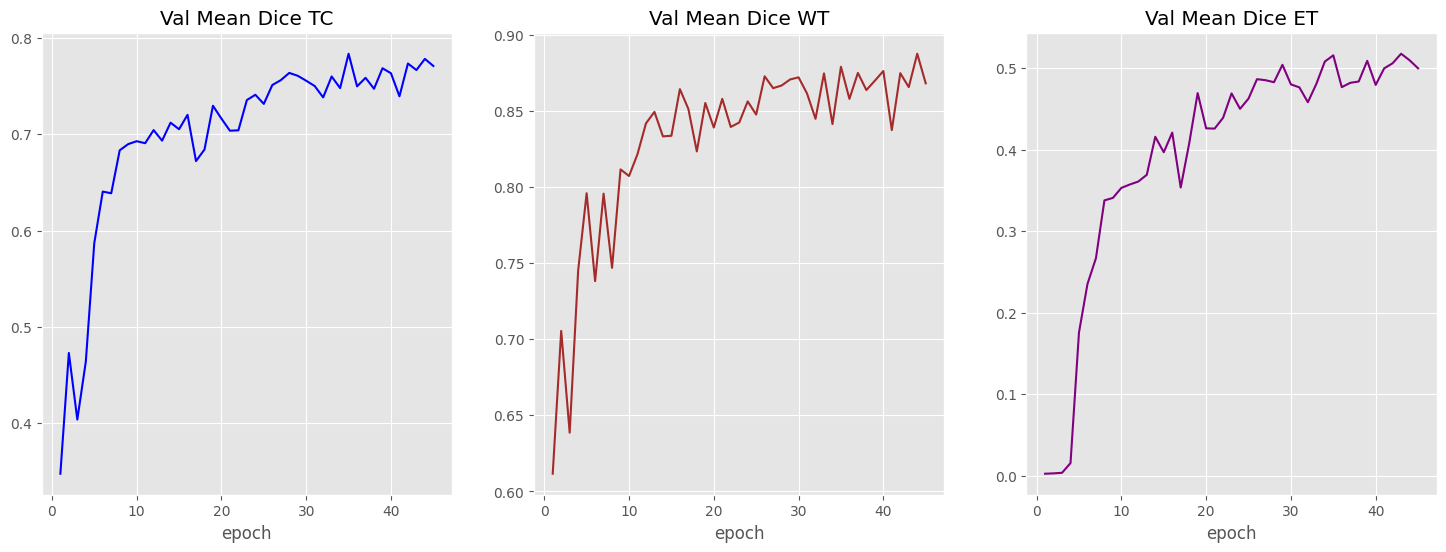

In [10]:
plt.figure('train', (12, 6))
plt.subplot(1, 2, 1)
plt.title('Epoch Average Loss')
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel('epoch')
plt.plot(x, y, color='red')
plt.subplot(1, 2, 2)
plt.title('Val Mean Dice')
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel('epoch')
plt.plot(x, y, color='green')
plt.savefig('../report/figures/val_loss_dice.jpg', dpi=300, bbox_inches=None)
plt.show()

plt.figure('train', (18, 6))
plt.subplot(1, 3, 1)
plt.title('Val Mean Dice TC')
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values_tc))]
y = metric_values_tc
plt.xlabel('epoch')
plt.plot(x, y, color='blue')
plt.subplot(1, 3, 2)
plt.title('Val Mean Dice WT')
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values_wt))]
y = metric_values_wt
plt.xlabel('epoch')
plt.plot(x, y, color='brown')
plt.subplot(1, 3, 3)
plt.title('Val Mean Dice ET')
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values_et))]
y = metric_values_et
plt.xlabel('epoch')
plt.plot(x, y, color='purple')

plt.savefig('../report/figures/val_dice_scores.jpg', dpi=300, bbox_inches=None)
plt.show()

<a name='print_training_values'></a>
### 4.2 <span style='color:blue'>|</span> Print Validation Loss and Dice Scores

In [11]:
print(f'Final Validation Loss Value:    {epoch_loss_values[-1]:.4f}')
print(f'Final Validation Dice Mean:     {metric_values[-1]:.4f}')
print(f'Final Validation Dice TC Value: {metric_values_tc[-1]:.4f}')
print(f'Final Validation Dice WT Value: {metric_values_wt[-1]:.4f}')
print(f'Final Validation Dice ET Value: {metric_values_et[-1]:.4f}')

Final Validation Loss Value:    0.4198
Final Validation Dice Mean:     0.7131
Final Validation Dice TC Value: 0.7710
Final Validation Dice WT Value: 0.8683
Final Validation Dice ET Value: 0.4998
